# K-means do zero, com distância periódica (PBC)

Este notebook reúne, de forma organizada e independente, o que foi desenvolvido em cima do exercício original (`01_exercicio_molsim.ipynb`): uma implementação de K-means escrita do zero, usando uma métrica de distância com correção de contorno periódico (PBC) para lidar corretamente com a periodicidade dos ângulos diedros.

Ele roda de forma autônoma (recarrega a trajetória e recalcula as features do zero), então funciona como uma alternativa/complemento ao notebook original, sem depender dele.

Fluxo:
1. Carregar a trajetória e calcular radius of gyration, RMSD e ângulos diedros
2. Implementar a distância com PBC e o algoritmo de K-means do zero
3. Rodar o clustering nas features globais (radius of gyration + RMSD)
4. Rodar o clustering nos ângulos diedros, com elbow plot, visualização via PCA e Ramachandran colorido por cluster
5. Extrair e visualizar a trajetória de um cluster específico
6. Conclusões e próximos passos

In [1]:
import MDAnalysis as mda
import nglview as nv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

from MDAnalysis.analysis import rms, align
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Fixing the random state for reproducibility
np.random.seed(19680801)
random.seed(19680801)  # o kmeans_clustering usa random.sample

## Carregando a trajetória e calculando as features

In [2]:
u = mda.Universe("trajectory.xyz", to_guess=['bonds', 'angles', 'dihedrals', 'masses'], dt=10)
u

<Universe with 42 atoms>

In [3]:
# Radius of gyration
molecule = u.select_atoms('all')
nframes = len(u.trajectory)
frame = np.zeros(nframes)
radgyr = np.zeros(nframes)

for ts in u.trajectory:
    frame[ts.frame] = ts.frame
    radgyr[ts.frame] = molecule.radius_of_gyration()

In [4]:
# RMSD em relação ao primeiro frame
R = rms.RMSD(u,             # universe to align
             u,              # reference universe or atomgroup
             select='all',   # group to superimpose and calculate RMSD
             ref_frame=0)    # frame index of the reference
R.run()
rmsd = R.results.rmsd[:, 2]

In [5]:
# Ângulos diedros (phi/psi de cada um dos 6 resíduos de alanina) e monta o dataframe de features
dihedral_indices = [3, 7, 15, 19, 27, 31, 39, 43, 51, 55, 63, 67]
dihedral_cols = [f"dihedral{i}" for i in dihedral_indices]

lst = []
for ts in u.trajectory:
    row = {"time": ts.time, "radgyr": radgyr[ts.frame], "rmsd": rmsd[ts.frame]}
    for col, idx in zip(dihedral_cols, dihedral_indices):
        row[col] = u.dihedrals[idx].value()
    lst.append(row)

df_features = pd.DataFrame(lst)

dihedrals_start_at = list(df_features.columns).index(dihedral_cols[0])
dihedral_names = df_features.columns[dihedrals_start_at:]

df_features.shape

(2000, 15)

## Distância com correção periódica (PBC)

Como os ângulos diedros são periódicos (-170° e 170° estão a só 20° de distância, não 340°), a distância euclidiana comum não serve. Usamos a correção de contorno periódico (PBC), com uma "caixa" de tamanho 360.

In [6]:
lbox = 360

def distance(x1, x2, lbox):
    d = x1 - x2
    d = d - lbox * np.round(d / lbox)
    r = np.linalg.norm(d)
    return r

# Teste: deve imprimir 28.284
structure1 = np.array([10.0, 170])
structure2 = np.array([30.0, -170])
print(f"Distance = {distance(structure1, structure2, lbox):6.3f}")

Distance = 28.284


## K-means implementado do zero

In [7]:
def kmeans_clustering(features, ncluster, lbox, maxcycle=100, plot=True):
    """Cluster `features` into `ncluster` clusters using our own K-means
    implementation with the periodic-boundary-corrected distance metric."""
    ndata, nfeature = features.shape
    centers = np.zeros((ncluster, nfeature))
    labels = [0] * ndata
    # we will compare the numbers of cluster members with those from the previous step to check convergence
    nmembers_prev = np.zeros(ncluster)
    angle_factor = 2 * np.pi / lbox

    # assign the cluster center positions to the positions of randomly chosen data points
    initial_indices = random.sample(range(ndata), ncluster)
    for ic, idata in enumerate(initial_indices):
        centers[ic] = features[idata]

    if plot:
        plt.figure(dpi=100)
        plt.scatter(features[:,0], features[:,1], c="LightGray")

    icycle = 0
    change = (nmembers_prev + 9999.0)
    while (change*change).sum() > 0 and icycle < maxcycle:
        # loop over data points and assign each to closest center, i.e. set data point label to cluster number
        for idata in range(ndata):
            rmin = 9999999.
            for ic in range(ncluster):
                r = distance(features[idata], centers[ic], lbox)
                if r < rmin:
                    rmin = r
                    labels[idata] = ic

        # recompute the cluster centers as the *circular* mean of their members.
        # A plain arithmetic mean is wrong for periodic features: e.g. averaging
        # +170 deg and -170 deg (only 20 deg apart on the circle) naively gives
        # 0 deg, a centroid on the opposite side of the circle from the data.
        labels_arr = np.array(labels)
        nmembers = np.zeros(ncluster)
        centers = np.zeros((ncluster, nfeature))
        for ic in range(ncluster):
            members = labels_arr == ic
            nmembers[ic] = members.sum()
            if nmembers[ic] > 0:
                theta = features[members] * angle_factor
                mean_sin = np.mean(np.sin(theta), axis=0)
                mean_cos = np.mean(np.cos(theta), axis=0)
                centers[ic] = np.arctan2(mean_sin, mean_cos) / angle_factor

        # compute the change in the numbers of members in this cycle
        change = (nmembers - nmembers_prev)
        nmembers_prev = nmembers
        icycle = icycle + 1

        # print some feedback and plot the new cluster centers
        print(f" cycle: {icycle:3d}, number of cluster members: {nmembers}")
        if plot:
            plt.scatter(centers[:,0], centers[:,1], c=range(ncluster), cmap='rainbow')

    if plot:
        plt.show()

        # plot a second plot with the cluster members coloured
        plt.figure(dpi=100)
        plt.scatter(features[:,0], features[:,1], c=labels, cmap='rainbow')
        plt.scatter(centers[:,0], centers[:,1], marker="x", c="Black")
        plt.show()

    return centers, np.array(labels), nmembers

## Clustering usando radius of gyration + RMSD

 cycle:   1, number of cluster members: [305.  63. 184. 179. 200. 462. 402. 205.]


 cycle:   2, number of cluster members: [335. 209. 189. 200. 148. 409. 277. 233.]


 cycle:   3, number of cluster members: [336. 220. 185. 201. 151. 406. 262. 239.]


 cycle:   4, number of cluster members: [336. 222. 173. 202. 166. 419. 247. 235.]


 cycle:   5, number of cluster members: [336. 222. 173. 206. 165. 421. 244. 233.]


 cycle:   6, number of cluster members: [336. 221. 174. 206. 165. 422. 244. 232.]


 cycle:   7, number of cluster members: [336. 221. 174. 206. 165. 422. 244. 232.]


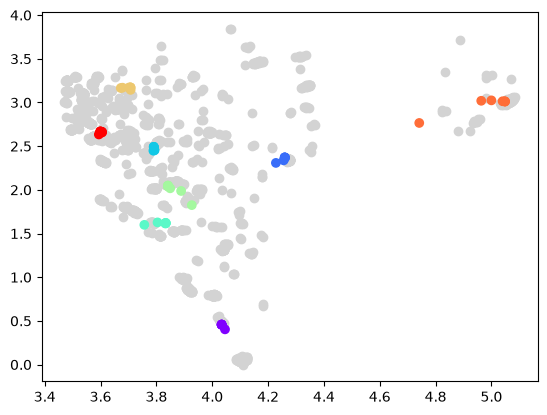

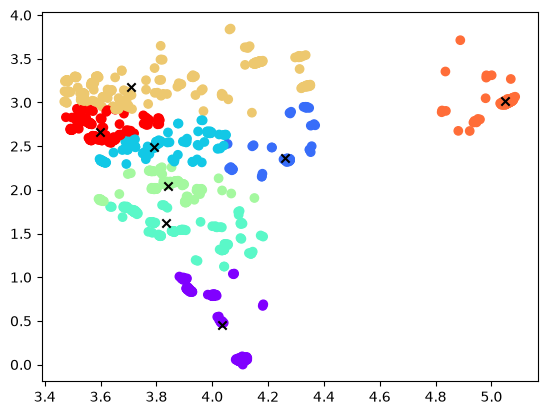

In [8]:
features = df_features.loc[:, ("radgyr", "rmsd")].values

ncluster = 8
centers, labels, nmembers = kmeans_clustering(features, ncluster, lbox)

Our K-means
Cluster centers:
[[4.03359896 0.45731462]
 [4.2599778  2.36895453]
 [3.79040638 2.49194027]
 [3.83326675 1.62062723]
 [3.84135277 2.04764291]
 [3.70740335 3.17157878]
 [5.0484     3.01191163]
 [3.59895309 2.66790004]]
Number of members in each cluster:
[336. 221. 174. 206. 165. 422. 244. 232.]


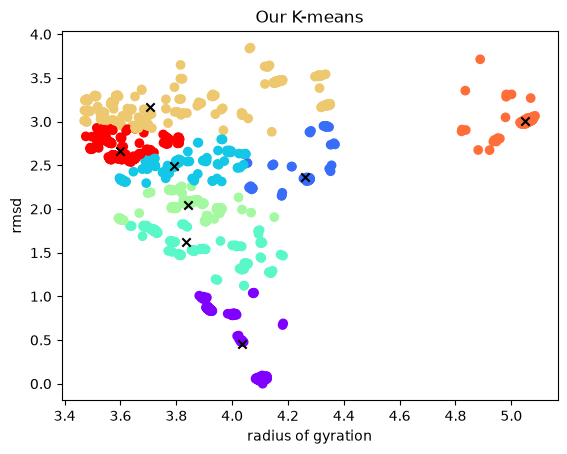


Scikit-Learn K-means
Cluster centers:
[[5.04839999 3.01191171]
 [3.68095471 2.56590517]
 [3.97946758 0.91305951]
 [3.56534363 3.09925405]
 [4.1070995  0.06000989]
 [3.81459247 1.84251763]
 [4.24079396 2.35260375]
 [4.1675273  3.33003744]]
Number of members in each cluster:
[244 392 209 338 163 317 227 110]


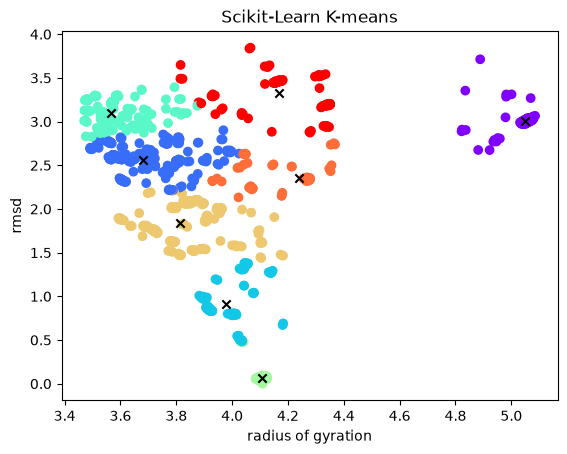

In [9]:
# Compara com o K-means do Scikit-Learn nas mesmas features e mesmo K
print("Our K-means")
print("Cluster centers:")
print(centers)
print("Number of members in each cluster:")
print(nmembers)

plt.figure(dpi=100)
plt.scatter(features[:,0], features[:,1], c=labels, cmap='rainbow')
plt.scatter(centers[:,0], centers[:,1], marker="x", c="black")
plt.xlabel("radius of gyration")
plt.ylabel("rmsd")
plt.title("Our K-means")
plt.show()

kmeans_sk = KMeans(n_clusters=ncluster, random_state=0).fit(features)
nmembers_sk = np.array([(kmeans_sk.labels_ == ic).sum() for ic in range(ncluster)])

print("\nScikit-Learn K-means")
print("Cluster centers:")
print(kmeans_sk.cluster_centers_)
print("Number of members in each cluster:")
print(nmembers_sk)

plt.figure(dpi=100)
plt.scatter(features[:,0], features[:,1], c=kmeans_sk.labels_, cmap='rainbow')
plt.scatter(kmeans_sk.cluster_centers_[:,0], kmeans_sk.cluster_centers_[:,1], marker="x", c="black")
plt.xlabel("radius of gyration")
plt.ylabel("rmsd")
plt.title("Scikit-Learn K-means")
plt.show()

## Clustering usando os ângulos diedros

In [10]:
# Agora as features são os 12 ângulos diedros (2 por resíduo)
features = df_features.loc[:, dihedral_names].values
features.shape

(2000, 12)

### Elbow plot para os ângulos diedros

Mesma ideia do elbow plot com Scikit-Learn, mas usando nossa `kmeans_clustering()` com a distância PBC. Como métrica de erro, usamos a soma das distâncias PBC² de cada ponto ao seu centroide.

Isso reroda o algoritmo do zero para vários valores de K, então pode demorar um pouco.

 cycle:   1, number of cluster members: [ 305. 1695.]
 cycle:   2, number of cluster members: [ 756. 1244.]
 cycle:   3, number of cluster members: [ 773. 1227.]
 cycle:   4, number of cluster members: [ 746. 1254.]
 cycle:   5, number of cluster members: [ 744. 1256.]
 cycle:   6, number of cluster members: [ 744. 1256.]
 k =  2, loss = 62066637.06
 cycle:   1, number of cluster members: [ 363.  491. 1146.]


 cycle:   2, number of cluster members: [363. 926. 711.]
 cycle:   3, number of cluster members: [ 329. 1037.  634.]
 cycle:   4, number of cluster members: [ 327. 1042.  631.]
 cycle:   5, number of cluster members: [ 330. 1044.  626.]
 cycle:   6, number of cluster members: [ 340. 1045.  615.]
 cycle:   7, number of cluster members: [ 346. 1045.  609.]


 cycle:   8, number of cluster members: [ 346. 1044.  610.]
 cycle:   9, number of cluster members: [ 346. 1044.  610.]
 k =  3, loss = 49086930.12
 cycle:   1, number of cluster members: [158. 444. 902. 496.]
 cycle:   2, number of cluster members: [154. 536. 845. 465.]
 cycle:   3, number of cluster members: [153. 547. 952. 348.]


 cycle:   4, number of cluster members: [153. 609. 963. 275.]
 cycle:   5, number of cluster members: [153. 604. 966. 277.]
 cycle:   6, number of cluster members: [153. 597. 966. 284.]
 cycle:   7, number of cluster members: [153. 592. 967. 288.]
 cycle:   8, number of cluster members: [153. 592. 967. 288.]


 k =  4, loss = 43590583.29
 cycle:   1, number of cluster members: [523. 206.  50. 793. 428.]
 cycle:   2, number of cluster members: [529. 273.  91. 616. 491.]
 cycle:   3, number of cluster members: [533. 250. 114. 619. 484.]


...

 cycle:   2, number of cluster members: [356.  97.  81.  58. 211. 389.  96.  73. 106.  94.  30.  89.  42. 278.]


 cycle:   3, number of cluster members: [358.  96.  80.  59. 194. 387.  98.  73. 135.  95.  52.  89.  42. 242.]


 cycle:   4, number of cluster members: [349.  96.  80.  59. 196. 362. 101.  73. 157.  98.  53.  88.  42. 246.]


 cycle:   5, number of cluster members: [346.  96.  80.  59. 196. 362. 101.  73. 157.  98.  53.  88.  42. 249.]


 cycle:   6, number of cluster members: [346.  96.  80.  59. 196. 362. 101.  73. 157.  98.  53.  88.  42. 249.]
 k = 14, loss = 17299840.53


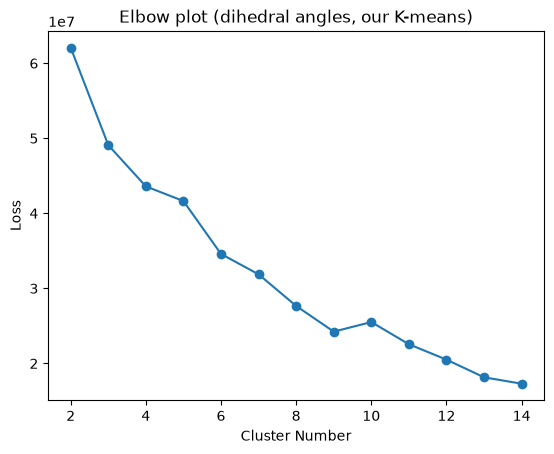

In [11]:
nclusters_dihedral = range(2, 15)
loss_dihedral = []

for k in nclusters_dihedral:
    centers_k, labels_k, nmembers_k = kmeans_clustering(features, k, lbox, plot=False)
    loss_k = sum(distance(features[i], centers_k[labels_k[i]], lbox) ** 2 for i in range(len(features)))
    loss_dihedral.append(loss_k)
    print(f" k = {k:2d}, loss = {loss_k:.2f}")

plt.figure(dpi=100)
plt.plot(nclusters_dihedral, loss_dihedral, "o-")
plt.xlabel("Cluster Number")
plt.ylabel("Loss")
plt.title("Elbow plot (dihedral angles, our K-means)")
plt.show()

 cycle:   1, number of cluster members: [1022.  327.  556.   95.]
 cycle:   2, number of cluster members: [959. 288. 592. 161.]
 cycle:   3, number of cluster members: [967. 292. 592. 149.]


 cycle:   4, number of cluster members: [967. 288. 592. 153.]
 cycle:   5, number of cluster members: [967. 288. 592. 153.]


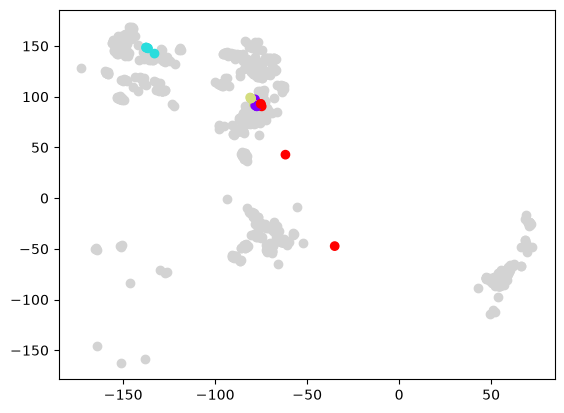

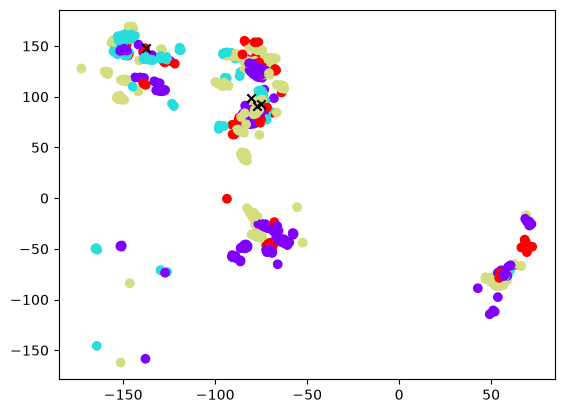

In [12]:
# Cotovelo principal em K=4 (com um segundo cotovelo mais fino perto de K=11)
ncluster = 4
centers, labels, nmembers = kmeans_clustering(features, ncluster, lbox)

**Partição de referência.** Uma rodada só do `kmeans_clustering` depende da inicialização: com 50 sementes diferentes, a trajetória de 500 K tem dezenas de mínimos locais distintos para K=4 (notebook 05, §1.1), e cada um dá populações e estabilidades diferentes. Para que as seções seguintes (PCA, Ramachandran, extração de clusters, ΔG, matriz de transição) sejam reprodutíveis e batam com o notebook 05, elas usam `canonical_states`: variante `corda`, melhor de 50 inicializações a partir da semente 0, estados numerados em ordem decrescente de população.

In [13]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from molsim.kmeans_variants import canonical_states

ref = canonical_states(features, k=ncluster)
centers, labels, nmembers = ref.centers, ref.labels, ref.n_members
print("membros por estado:", nmembers)

membros por estado: [580 575 566 279]


### Visualizando os clusters dos diedros com PCA

Com 12 features não dá mais pra plotar feature 0 vs feature 1 diretamente. Projetamos as 12 dimensões nos 2 primeiros componentes principais (PCA) e colorimos cada ponto pelo rótulo do cluster.

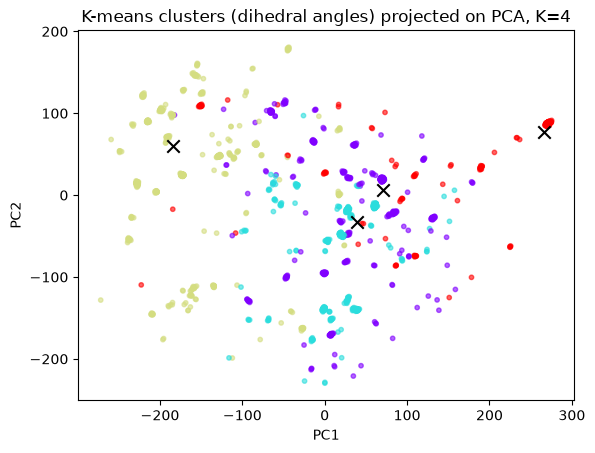

Variance explained by PC1+PC2: 55.96%


In [14]:
pca_dihedral = PCA(n_components=2)
features_2d = pca_dihedral.fit_transform(features)
centers_2d = pca_dihedral.transform(centers)

plt.figure(dpi=100)
plt.scatter(features_2d[:,0], features_2d[:,1], c=labels, cmap='rainbow', s=10, alpha=0.6)
plt.scatter(centers_2d[:,0], centers_2d[:,1], marker="x", c="black", s=80)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clusters (dihedral angles) projected on PCA, K={ncluster}")
plt.show()

print(f"Variance explained by PC1+PC2: {pca_dihedral.explained_variance_ratio_.sum():.2%}")

In [15]:
print("Cluster centers:")
print(centers)
print("Number of members in each cluster:")
print(nmembers)
centers.shape

Cluster centers:
[[ -78.60626811   83.04833176  -72.54807881   96.91258298  -80.00376484
   117.90089285 -112.66318272   95.1986137   -69.16074515   76.34519212
   -67.83582295   72.22664835]
 [ -73.88149231   99.90770975  -78.4763384    83.0413063   -65.17348271
   129.10628317 -108.36342579   41.65553022 -110.13553621  -56.52003697
   -99.39052829   66.06920577]
 [ -82.04776048   99.96884983   10.25838258  -60.90927274  -96.96219189
   110.56027297 -114.75922021  117.59604998   60.4286965   -62.53696928
   -87.50374369   14.041717  ]
 [-140.60798877  150.78909696 -153.22693526  176.05408168  -95.17699264
   111.97630053 -117.68437001  105.07572166 -161.53935614  159.15665554
  -132.47939297  145.7948471 ]]
Number of members in each cluster:
[580 575 566 279]


(4, 12)

### Ramachandran (phi vs psi) colorido por cluster

Grid 2x3, um subplot por resíduo, mostrando phi vs psi coloridos pelo rótulo do cluster -- dá pra comparar com um Ramachandran plot padrão da alanina.

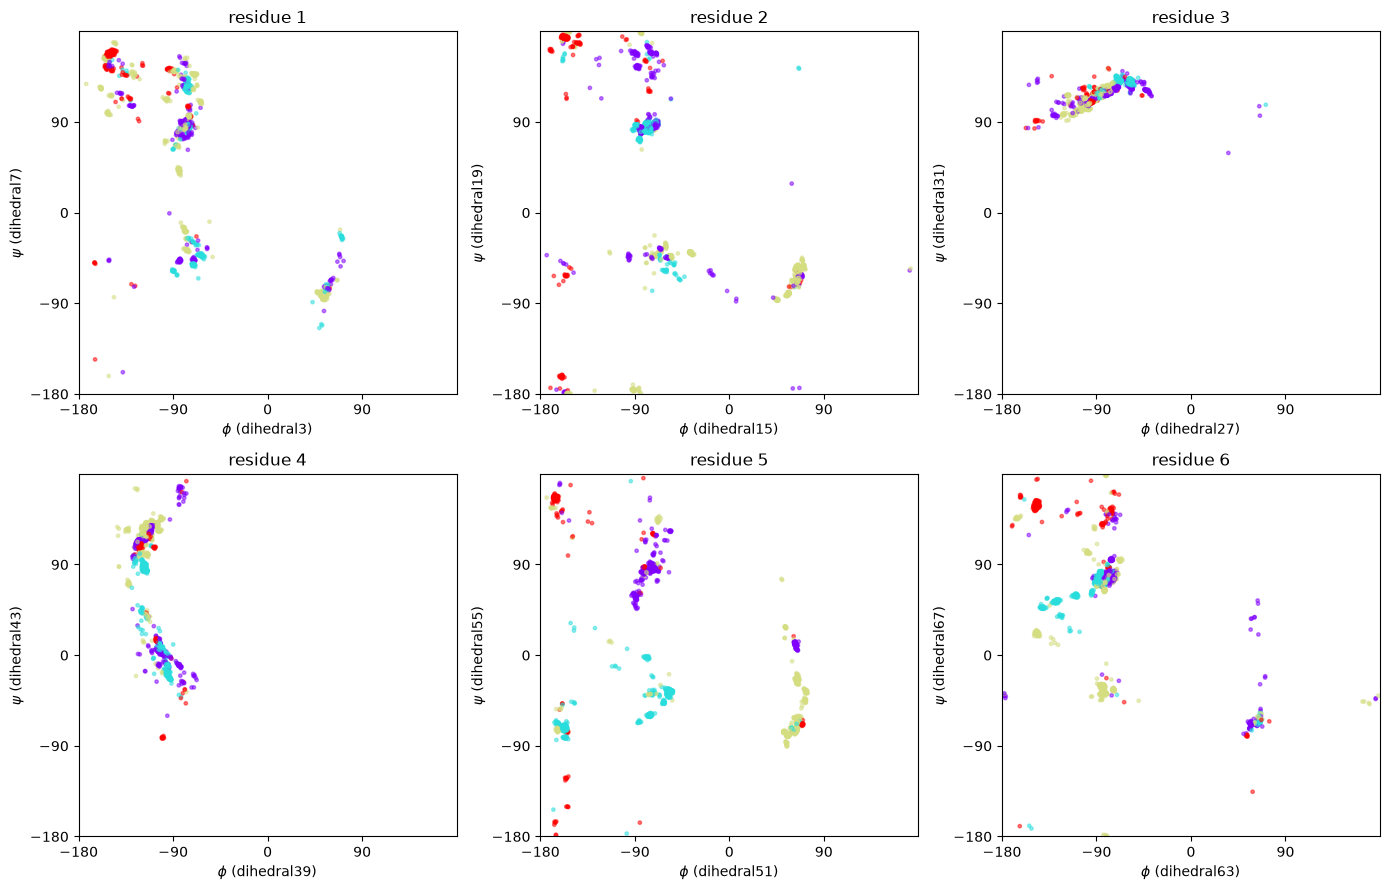

In [16]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(14, 9))
axs = axs.flatten()
for i, ax in enumerate(axs):
    phi_name, psi_name = dihedral_names[2 * i], dihedral_names[2 * i + 1]
    ax.scatter(df_features[phi_name], df_features[psi_name], s=6, alpha=0.5, c=labels, cmap='rainbow')
    ax.set(xlim=(-180, 180), ylim=(-180, 180),
           xticks=np.arange(-180, 180, 90), yticks=np.arange(-180, 180, 90))
    ax.set_xlabel(r"$\phi$" + f" ({phi_name})")
    ax.set_ylabel(r"$\psi$" + f" ({psi_name})")
    ax.set_title(f"residue {i + 1}")
plt.tight_layout()
plt.show()

## Extraindo e visualizando um cluster específico

In [17]:
# Repita esta célula trocando "iclus" para inspecionar cada cluster
iclus = 0
print(f"Cluster: {iclus}, número de membros: {int(nmembers[iclus])}")

bools = labels == iclus
filename = f"cluster_{iclus}.xyz"
u.select_atoms("all").write(filename, frames=u.trajectory[bools])

u_cluster = mda.Universe(filename, to_guess=['bonds', 'angles', 'dihedrals', 'masses'], dt=10)
ref = mda.Universe(filename, to_guess=['bonds', 'angles', 'dihedrals', 'masses'], dt=10)
aligner = align.AlignTraj(u_cluster, ref, select='all', in_memory=True).run()

w = nv.show_mdanalysis(u_cluster)
w

Cluster: 0, número de membros: 580


NGLWidget(max_frame=579)

## Energia livre relativa

$\Delta G(i) = -k_B T \ln(n_i / n_{max})$, direto do `nmembers` da partição de referência.

cluster 0: 580 membros (29.0%)  dG = -0.00 kcal/mol
cluster 1: 575 membros (28.7%)  dG = 0.01 kcal/mol
cluster 2: 566 membros (28.3%)  dG = 0.02 kcal/mol
cluster 3: 279 membros (14.0%)  dG = 0.73 kcal/mol


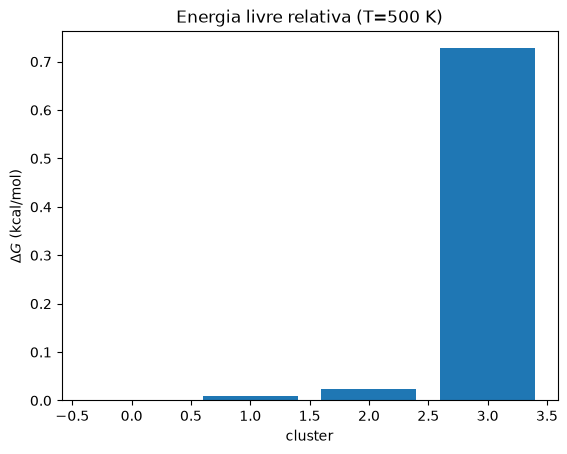

In [18]:
KB = 0.0019872041  # kcal/(mol*K)
T = 500.0

pop = nmembers / nmembers.sum()
dG = -KB * T * np.log(pop / pop.max())

for i in range(ncluster):
    print(f"cluster {i}: {int(nmembers[i])} membros ({100*pop[i]:.1f}%)  dG = {dG[i]:.2f} kcal/mol")

plt.figure(dpi=100)
plt.bar(range(ncluster), dG)
plt.xlabel("cluster")
plt.ylabel(r"$\Delta G$ (kcal/mol)")
plt.title(f"Energia livre relativa (T={T:.0f} K)")
plt.show()

## Matriz de transicao

Conta, no array `labels` (que ja esta em ordem temporal), quantas vezes o estado $i$ e' seguido pelo estado $j$, e normaliza cada linha para virar probabilidade.

Matriz de transicao (linha = estado inicial, coluna = estado final):
[[0.609 0.117 0.083 0.191]
 [0.123 0.779 0.019 0.078]
 [0.081 0.018 0.881 0.019]
 [0.394 0.172 0.032 0.401]]


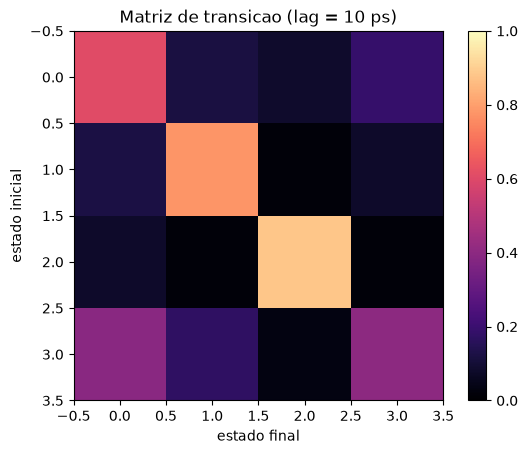

In [19]:
Tm = np.zeros((ncluster, ncluster))
for i in range(len(labels) - 1):
    Tm[labels[i], labels[i + 1]] += 1

Tm_norm = Tm / Tm.sum(axis=1, keepdims=True)
print("Matriz de transicao (linha = estado inicial, coluna = estado final):")
print(np.round(Tm_norm, 3))

plt.figure(dpi=100)
plt.imshow(Tm_norm, cmap="magma", vmin=0, vmax=1)
plt.xlabel("estado final")
plt.ylabel("estado inicial")
plt.title("Matriz de transicao (lag = 10 ps)")
plt.colorbar()
plt.show()

Os estados 0, 1 e 2 têm população parecida (~28–29% cada) e energia livre praticamente igual (diferenças de centésimos de kcal/mol, bem dentro da incerteza estatística; o IC95 por bootstrap está no notebook 05) — três estados igualmente prováveis. O estado 3 é menor (14%, ΔG ≈ 0,7 kcal/mol) e o mais instável: a probabilidade de permanecer nele após 10 ps é só 0,40 (contra 0,61–0,88 dos outros três), e ele migra para o estado 0 quase tanto quanto fica onde está (0,39) — sinal de que é uma região de passagem, não um estado metaestável por si só.

A matriz de transição a um único tempo de atraso não basta para decidir se esses estados são metaestáveis. O teste completo (tempos de residência, escalas de tempo implícitas em função do atraso, microestados) está no notebook `05_cinetica.ipynb`.

## Comparação das três variantes (programa de medida §3.3)

O `kmeans_clustering` acima é a variante **mista** da §3.2 do `PLANO.md`: atribuição por imagem mínima, atualização por média circular. Ela é uma correção parcial — a média circular é melhor que a aritmética, mas não é o minimizador exato da distância de imagem mínima usada na atribuição. Só a variante **corda** (atribuição por Σ(1 − cos Δθ), cujo minimizador exato *é* a média circular) tem essa garantia.

As três variantes, com instrumentação (histórico do objetivo, detecção de ciclo limite guardando as partições visitadas) e o programa de medida da §3.3, foram portadas para [`molsim/kmeans_variants.py`](../molsim/kmeans_variants.py) e testadas em [`tests/test_kmeans_variants.py`](../tests/test_kmeans_variants.py) — inclusive reproduzindo os números exatos do exemplo da §3.1 (Σd² = 119050 vs 250). Esta seção roda esse módulo contra os diedros desta trajetória (500 K).


In [20]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from molsim.kmeans_variants import VARIANTS, convergence_program, discontinuity_fraction

features_dihedral = df_features.loc[:, dihedral_names].values

frac = discontinuity_fraction(features_dihedral, threshold_deg=40.0)
print(f"Fração de amostras a menos de 40° da descontinuidade ±180°: {frac:.1%}")
print("(confirma a estimativa de 11,6% da §3.1 do PLANO.md: não é caso patológico, é típico)")


Fração de amostras a menos de 40° da descontinuidade ±180°: 11.6%
(confirma a estimativa de 11,6% da §3.1 do PLANO.md: não é caso patológico, é típico)


In [21]:
import pandas as pd

# Roda as tres variantes, com 50 inicializacoes aleatorias cada, para K de 2 a 12.
# Leva uns 15-20s no total (o kmeans_periodic e vetorizado e roda em poucos ms por chamada).
rows = []
for k in range(2, 13):
    for variant in VARIANTS:
        stats = convergence_program(features_dihedral, k=k, variant=variant,
                                     n_init=50, seed0=0, max_iter=200)
        rows.append(dict(
            k=k, variant=variant,
            taxa_convergencia=stats.rate_converged,
            taxa_ciclo_limite=stats.rate_cycled,
            violacoes_monotonicidade=stats.monotonic_violations,
            media_iteracoes=stats.mean_n_iter,
        ))

tabela_comparativa = pd.DataFrame(rows)
tabela_comparativa

,k,variant,taxa_convergencia,taxa_ciclo_limite,violacoes_monotonicidade,media_iteracoes
0,2,tutorial,1.00,0.00,34,8.42
1,2,mista,1.00,0.00,22,8.24
2,2,corda,1.00,0.00,0,6.80
3,3,tutorial,0.86,0.14,43,10.06
4,3,mista,1.00,0.00,39,9.42
5,3,corda,1.00,0.00,0,8.46
6,4,tutorial,0.72,0.28,46,10.80
7,4,mista,1.00,0.00,38,10.00
8,4,corda,1.00,0.00,0,8.94
9,5,tutorial,0.50,0.50,49,11.52


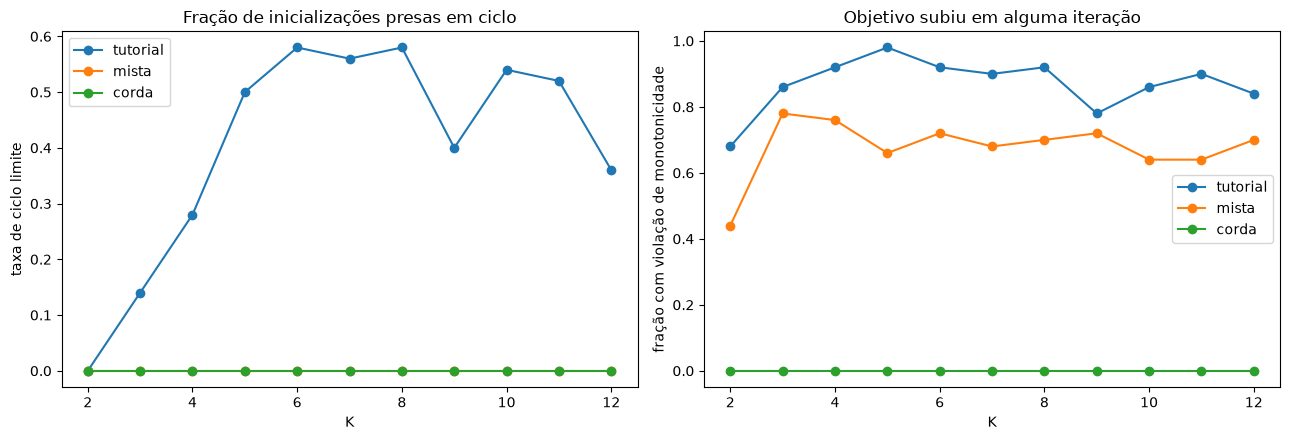

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)

for variant in VARIANTS:
    sub = tabela_comparativa[tabela_comparativa.variant == variant]
    ax1.plot(sub.k, sub.taxa_ciclo_limite, "o-", label=variant)
    ax2.plot(sub.k, sub.violacoes_monotonicidade / 50, "o-", label=variant)

ax1.set_xlabel("K"); ax1.set_ylabel("taxa de ciclo limite")
ax1.set_title("Fração de inicializações presas em ciclo")
ax1.legend()

ax2.set_xlabel("K"); ax2.set_ylabel("fração com violação de monotonicidade")
ax2.set_title("Objetivo subiu em alguma iteração")
ax2.legend()

plt.tight_layout()
plt.show()

**Resultado** (rodado uma vez para conferência; os números exatos podem variar um pouco por causa da aleatoriedade do float, mas o padrão é estável):

- **`tutorial`** (a variante do material de referência) cicla em **14% a 58%** das inicializações, dependendo de K — nunca menos que isso a partir de K=3 — e viola a monotonicidade do objetivo em **quase todas as rodadas** (34 a 49 em 50), inclusive nas que eventualmente "convergem". Isto é o defeito da §3.1 acontecendo de fato, não só em teoria: a atualização por média aritmética empurra o centroide para o lado errado do círculo perto da descontinuidade ±180°, o algoritmo sobe no objetivo, e frequentemente fica preso alternando entre duas partições.
- **`mista`** nunca cicla e converge em 100% das rodadas — mas ainda viola a monotonicidade em uma fração substancial delas (22 a 46 em 50, dependendo de K). Isso é exatamente a previsão da §3.2: a média circular é uma correção real (elimina o ciclo limite), mas não é o minimizador exato da distância de imagem mínima usada na atribuição, então a garantia de monotonicidade não vale.
- **`corda`** converge em 100% das rodadas e tem **zero violações de monotonicidade em todas as combinações de K testadas** (11 valores de K × 50 sementes = 550 rodadas). É a única variante em que a atualização é o minimizador exato da métrica de atribuição, e o resultado empírico bate com a garantia teórica.

Isso fecha o programa de medida da §3.3: a hipótese da §3 — que a variante do material de referência é incoerente e isso tem consequência prática — está demonstrada quantitativamente sobre a trajetória real, não só no exemplo sintético de 4 pontos.

**O que ainda falta para fechar a Fase B:** os baselines (GMM, aglomerativo/Ward, e concordância por ARI entre os métodos) e decidir, com base na física (não só no cotovelo), qual K usar para a interpretação final dos estados — isso é o objetivo da Fase C.


## Baselines: GMM, aglomerativo (Ward) e DBSCAN — concordância por ARI

Falta comparar o K-means periódico contra métodos que não foram desenvolvidos para este problema específico. Fixamos K=4 (o cotovelo escolhido acima) para GMM, Ward e o K-means do scikit-learn, e rodamos o DBSCAN com os mesmos parâmetros do notebook `03_dbscan.ipynb` (eps=30, min_samples=12, que encontra sozinho 34 clusters + ruído).

**Ressalva importante:** GMM, Ward e DBSCAN do scikit-learn usam distância euclidiana comum nos ângulos crus — não entendem que -179° e 179° são vizinhos. Só `corda` e `mista` são periódicos. Isso é proposital: queremos ver se essa diferença de tratamento da periodicidade aparece na concordância entre os métodos.

Medimos a concordância com o Adjusted Rand Index (ARI): 1.0 = partições idênticas (a menos de renomear rótulos), 0.0 = concordância não melhor que acaso.

In [23]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
from molsim.kmeans_variants import kmeans_periodic

K_BASELINE = 4

r_corda = kmeans_periodic(features_dihedral, k=K_BASELINE, variant="corda", seed=0)
r_mista = kmeans_periodic(features_dihedral, k=K_BASELINE, variant="mista", seed=0)

kmeans_sk = KMeans(n_clusters=K_BASELINE, random_state=0, n_init=10).fit(features_dihedral)
gmm_labels = GaussianMixture(n_components=K_BASELINE, random_state=0).fit_predict(features_dihedral)
ward_labels = AgglomerativeClustering(n_clusters=K_BASELINE, linkage="ward").fit_predict(features_dihedral)
dbscan_labels = DBSCAN(eps=30.0, min_samples=12).fit(features_dihedral).labels_

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN encontrou {n_clusters_db} clusters + {(dbscan_labels == -1).sum()} pontos de ruído")

metodos = {
    "corda": r_corda.labels,
    "mista": r_mista.labels,
    "kmeans_sklearn": kmeans_sk.labels_,
    "gmm": gmm_labels,
    "ward": ward_labels,
    "dbscan": dbscan_labels,
}

DBSCAN encontrou 34 clusters + 486 pontos de ruído


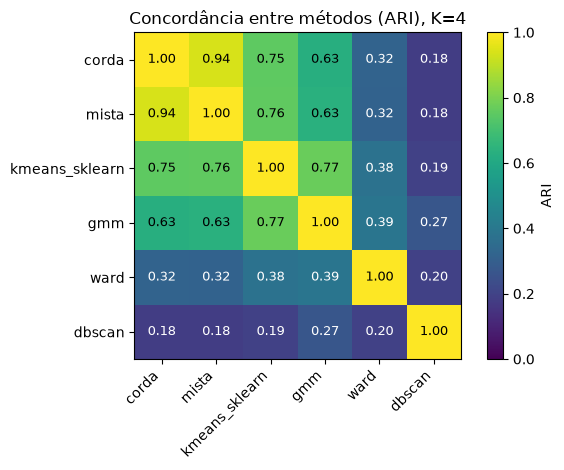

,corda,mista,kmeans_sklearn,gmm,ward,dbscan
corda,1.000,0.941,0.752,0.628,0.317,0.182
mista,0.941,1.000,0.756,0.635,0.315,0.183
kmeans_sklearn,0.752,0.756,1.000,0.770,0.378,0.194
gmm,0.628,0.635,0.770,1.000,0.388,0.269
ward,0.317,0.315,0.378,0.388,1.000,0.195
dbscan,0.182,0.183,0.194,0.269,0.195,1.000


In [24]:
nomes = list(metodos)
ari = pd.DataFrame(index=nomes, columns=nomes, dtype=float)
for a in nomes:
    for b in nomes:
        ari.loc[a, b] = adjusted_rand_score(metodos[a], metodos[b])

plt.figure(dpi=100)
plt.imshow(ari.values, cmap="viridis", vmin=0, vmax=1)
plt.xticks(range(len(nomes)), nomes, rotation=45, ha="right")
plt.yticks(range(len(nomes)), nomes)
for i in range(len(nomes)):
    for j in range(len(nomes)):
        plt.text(j, i, f"{ari.values[i, j]:.2f}", ha="center", va="center",
                  color="white" if ari.values[i, j] < 0.6 else "black", fontsize=9)
plt.title(f"Concordância entre métodos (ARI), K={K_BASELINE}")
plt.colorbar(label="ARI")
plt.tight_layout()
plt.show()

ari.round(3)

**Resultado** (ARI, arredondado):

|  | corda | mista | kmeans_sklearn | gmm | ward | dbscan |
|---|---|---|---|---|---|---|
| **corda** | 1.00 | 0.94 | 0.75 | 0.63 | 0.32 | 0.18 |
| **mista** | 0.94 | 1.00 | 0.76 | 0.64 | 0.32 | 0.18 |
| **kmeans_sklearn** | 0.75 | 0.76 | 1.00 | 0.77 | 0.38 | 0.19 |
| **gmm** | 0.63 | 0.64 | 0.77 | 1.00 | 0.39 | 0.27 |
| **ward** | 0.32 | 0.32 | 0.38 | 0.39 | 1.00 | 0.20 |
| **dbscan** | 0.18 | 0.18 | 0.19 | 0.27 | 0.20 | 1.00 |

Um gradiente nítido, e ele segue exatamente a hipótese do projeto:

- **`corda` e `mista` concordam fortemente entre si (0.94)** — os dois tratam a periodicidade, e chegam essencialmente à mesma partição.
- **Concordância cai à medida que o método se afasta do tratamento periódico**: K-means euclidiano comum (0.75), GMM (0.63), Ward (0.32), DBSCAN (0.18 — mas aqui a comparação é injusta, porque o DBSCAN não usa K=4, ele mesmo decidiu por 34 grupos + ruído).
- **Ward é o caso mais claro de método inadequado**: concorda pouco com todo mundo, inclusive com K-means/GMM euclidianos (0.38-0.39) — a estrutura hierárquica que ele impõe não corresponde bem à geometria dos dados, periódica ou não.

Isso não prova que `corda`/`mista` estão "certos" e o resto "errado" — mas mostra que **a escolha do método muda a resposta de forma substancial**, o que é justamente o ponto da §4 do plano: o critério geométrico sozinho não define os estados de forma robusta. Falta o critério cinético (Fase C) para desempatar.

## Conclusões e próximos passos

**Question 7** — respondida no notebook `05_cinetica.ipynb`, §6:
- Qual conjunto de features performou melhor para o clustering (radius of gyration + RMSD vs. ângulos diedros), e por quê?
- Quantos estados metaestáveis a molécula parece ter, com base no elbow plot dos diedros (cotovelo principal em K≈4, secundário em K≈11)?

**Ideias para o próximo notebook:**
- ✅ *(feito acima e no notebook 05, com IC95)* **Energia livre relativa dos clusters**: usar $\Delta G(i) = -k_B T \ln(n_i / N)$ para estimar a energia livre relativa de cada estado metaestável, a partir do número de membros de cada cluster.
- ✅ *(feito no notebook 05: escalas de tempo implícitas, microestados, macroestados)* **Matriz de transição / Markov State Model**: contar, no array `labels`, quantas vezes o estado $i$ é seguido pelo estado $j$ ao longo do tempo, dividir pelo tempo total de simulação para estimar a matriz de transição, e visualizar como um grafo 2D dos estados e suas transições.
- **Clustering usando todas as features juntas** (diédros + radius of gyration + RMSD) -- combinação ainda não testada aqui, mencionada como terceira abordagem no exercício original.
- **Comparar os dois clusterings** (radgyr/rmsd vs. diédros): percorrer os dois arrays de `labels` e contar quantos pontos foram classificados de forma diferente (exige alinhar os índices dos clusters entre as duas rodadas, por exemplo inicializando os centroides com os pontos mais próximos dos centroides de uma rodada anterior).
- ✅ *(feito no notebook 05, §5.1, na imersão (cos θ, sin θ))* **KNN supervisionado**: usar os dados rotulados dessa simulação a T=500K para classificar, via K-Nearest Neighbors, uma nova trajetória simulada a T=300K (ideia mencionada no notebook original).